This is the preprocessing file for loading in the data finding and assigning bad channels and using ICA to identify false components

In [129]:
#loading in req. packages
import mne
import matplotlib.pyplot as plt
import os
import numpy as np
import os.path as op
import warnings
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
)
from mne.preprocessing import find_bad_channels_maxwell
import sys
import scipy

warnings.filterwarnings('ignore')


In [130]:
PSD_FMIN, PSD_FMAX = 1.0, 150.0
PSD_Z_THRESH = 3.5
RNG = 97

# Frequency heuristics for ICA component rejection
LOW_DRIFT_HZ = 1.0
HIGH_NOISE_HZ = 80.0
VAR_THRESHOLD_Z = 3.5  # reject components with z-var > this

In [131]:
def _robust_z(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + np.finfo(float).eps
    return (x - med) / (1.4826 * mad)

def detect_bad_channels_psd(raw, fmin=PSD_FMIN, fmax=PSD_FMAX, z_thresh=PSD_Z_THRESH):
    spec = raw.compute_psd(fmin=fmin, fmax=fmax, method='welch')
    psds, freqs = spec.get_data(return_freqs=True)
    total_log_power = np.log(psds.sum(axis=1) + np.finfo(float).eps)
    z = _robust_z(total_log_power)
    bads = [ch for ch, zi in zip(raw.ch_names, z) if zi > z_thresh]
    return bads

def detect_flat_channels(raw, std_thresh=1e-12):
    data = raw.get_data()
    stds = data.std(axis=1)
    return [ch for ch, s in zip(raw.ch_names, stds) if s < std_thresh]

def fit_ica(raw, rng=RNG):
    ica_raw = raw.copy().load_data()
    ica_raw.filter(l_freq=1.0, h_freq=None)
    picks_meg = mne.pick_types(raw.info, meg=True, exclude="bads")

    ica = mne.preprocessing.ICA(
        n_components=0.99, random_state=rng, method="fastica", max_iter="auto"
    )
    ica.fit(ica_raw, picks=picks_meg)
    return ica

def auto_reject_ica_components(ica, raw):
    """Automatically flag ICA components that look like noise."""
    sources = ica.get_sources(raw).get_data()
    n_comp = sources.shape[0]

    # Compute PSD per component
    psd = np.abs(np.fft.rfft(sources, axis=1)) ** 2
    freqs = np.fft.rfftfreq(sources.shape[1], 1.0 / raw.info["sfreq"])

    low_mask = freqs < LOW_DRIFT_HZ
    high_mask = freqs > HIGH_NOISE_HZ

    low_power = psd[:, low_mask].sum(axis=1)
    high_power = psd[:, high_mask].sum(axis=1)
    total_power = psd.sum(axis=1)

    frac_low = low_power / total_power
    frac_high = high_power / total_power

    # Reject components with dominant low (<1 Hz) or high (>80 Hz) power
    bad_low = np.where(frac_low > 0.5)[0]
    bad_high = np.where(frac_high > 0.5)[0]

    # Reject components with extreme variance
    var_z = _robust_z(sources.var(axis=1))
    bad_var = np.where(var_z > VAR_THRESHOLD_Z)[0]

    bads = np.unique(np.concatenate([bad_low, bad_high, bad_var]))
    return list(map(int, bads))

In [132]:
def opm_preproc_auto(raw):
    raw = raw.copy().load_data()

    # 1. Detect bad channels
    auto_bads_psd = detect_bad_channels_psd(raw)
    auto_bads_flat = detect_flat_channels(raw)
    raw.info["bads"] = sorted(set(auto_bads_psd + auto_bads_flat))
    print(f"Auto-detected bad channels: {raw.info['bads']}")

    # 2. Apply 44 Hz and 50 Hz + harmonics notch filters
    raw.notch_filter(freqs=[44, 50, 100, 150, 200], picks="meg", verbose="error")
    print(f"Applied 44 Hz and 50 Hz + harmonics notch filters")

    # 3. ICA fit
    ica = fit_ica(raw)

    # 4. Automatically reject noise-like components
    bad_comps = auto_reject_ica_components(ica, raw)
    ica.exclude = bad_comps
    print(f"Automatically excluded ICA components: {ica.exclude}")

    # 5. Apply ICA
    ica.apply(raw)
    print("Applied ICA artifact removal.")

    # 6. Interpolate bad channels
    if raw.info["bads"]:
        if raw.info.get("dig") is None:
            print("Skipping bad-channel interpolation (no digitization data found).")
        else:
            raw.interpolate_bads(reset_bads=False)
            print("Interpolated bad channels.")

    return raw, ica


In [133]:
# load in data
subject = '01'
session = '01'
task = 'face'
run = '01'

bids_root = '/Users/rekaforgo/Documents/Bachelor2025'

# Original raw file
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    run=run,
    suffix='meg',
    extension='.fif',
    root=bids_root
)

# --- LOAD RAW DATA ---
raw = read_raw_bids(bids_path=bids_path, verbose=True)
print(f"Loaded: {bids_path.fpath}")

Resolving symbolic link: /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif -> /Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif
Opening raw data file /Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif...
Isotrak not found
    Range : 0 ... 325339 =      0.000 ...   325.339 secs
Ready.
Reading events from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_events.tsv.
Reading channel info from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_channels.tsv.
Loaded: /Users/rekaforgo/Documents/B

In [134]:
#run preprocessing pipeline

clean_raw, ica = opm_preproc_auto(raw)

Reading 0 ... 325339  =      0.000 ...   325.339 secs...
Effective window size : 2.048 (s)
Auto-detected bad channels: ['MEG05', 'MEG08', 'MEG16', 'MEG18', 'MEG29', 'MEG38', 'MEG40', 'MEG46', 'MEG47', 'MEG61', 'MEG64']
Applied 44 Hz and 50 Hz + harmonics notch filters
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Fitting ICA to data using 53 channels (please be patient, this may take a while)
Selecting by explained variance: 3 components
Fitting ICA took 3.7s.
Automatically excluded ICA components: [0, 1, 2]
Applying ICA to Raw instance
    Transforming to ICA space (3 components)
    Zeroing out 3 ICA components
    Projecting back using 53 PCA components
Applied ICA artifact removal.
Skipping bad-channel interpolation (no digitization data found).


In [137]:
deriv_root = op.join(bids_root, 'derivatives', 'preprocessing')
os.makedirs(deriv_root, exist_ok=True)
deriv_path = bids_path.copy().update(
    root=deriv_root,
    description="clean",                    
    datatype="meg",
    extension=".fif",
    check=False,
)
clean_raw.save(deriv_path.fpath, overwrite=True)
print(f"Cleaned data saved to: {deriv_path.fpath}")

Writing /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_desc-clean_meg.fif
Closing /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_desc-clean_meg.fif
[done]
Cleaned data saved to: /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_desc-clean_meg.fif


Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


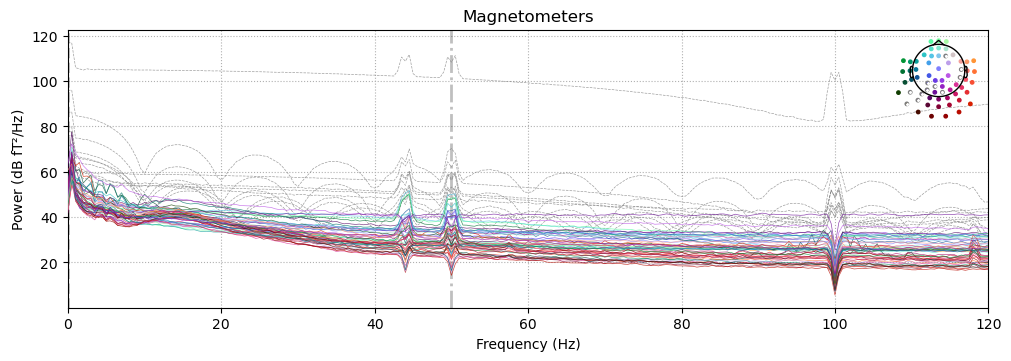

In [ ]:
n_fft = 2000 # achieving a 0.5 Hz frequency resolution
clean_psd = clean_raw.compute_psd('welch', fmin=0.0, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft // 2))

clean_psd.plot(picks="mag")